In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [3]:
data={
    'study_hours' : [10,5,15,8,3,12,9,4,16,7],
    'attendances' : [85,65,90,75,60,95,80,50,100,70],
    'previous_grades':[80,60,85,70,55,90,80,50,95,65],
    'age':[18,20,19,21,22,20,19,18,21,20],
    'family_support':[1,0,1,1,0,1,1,0,1,0],
    'pass_fail':[1,0,1,1,0,1,1,0,1,0]
}


In [4]:
df=pd.DataFrame(data)

In [5]:
df

,study_hours,attendances,previous_grades,age,family_support,pass_fail
0,10,85,80,18,1,1
1,5,65,60,20,0,0
2,15,90,85,19,1,1
3,8,75,70,21,1,1
4,3,60,55,22,0,0
5,12,95,90,20,1,1
6,9,80,80,19,1,1
7,4,50,50,18,0,0
8,16,100,95,21,1,1
9,7,70,65,20,0,0


In [6]:
df.describe()

,study_hours,attendances,previous_grades,age,family_support,pass_fail
count,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000
mean,8.900000,77.00000,73.000000,19.800000,0.600000,0.600000
std,4.433459,16.02082,15.311579,1.316561,0.516398,0.516398
min,3.000000,50.00000,50.000000,18.000000,0.000000,0.000000
25%,5.500000,66.25000,61.250000,19.000000,0.000000,0.000000
50%,8.500000,77.50000,75.000000,20.000000,1.000000,1.000000
75%,11.500000,88.75000,83.750000,20.750000,1.000000,1.000000
max,16.000000,100.00000,95.000000,22.000000,1.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   study_hours      10 non-null     int64
 1   attendances      10 non-null     int64
 2   previous_grades  10 non-null     int64
 3   age              10 non-null     int64
 4   family_support   10 non-null     int64
 5   pass_fail        10 non-null     int64
dtypes: int64(6)
memory usage: 612.0 bytes


In [8]:
df.isnull().sum()

study_hours        0
attendances        0
previous_grades    0
age                0
family_support     0
pass_fail          0
dtype: int64

<Axes: >

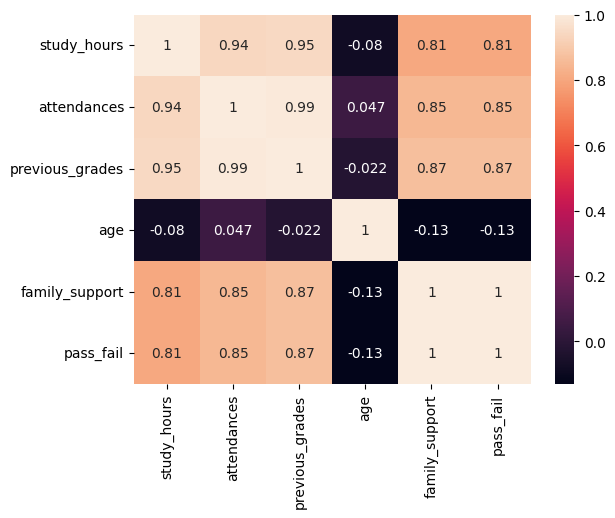

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [10]:
X=df[['study_hours','attendances','previous_grades','family_support']]
y=df['pass_fail']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [12]:
print("X_train",X_train.shape)
print("Y_train",y_train.shape)

X_train (7, 4)
Y_train (7,)


In [13]:
print("X_test",X_test.shape)
print("Y_test",y_test.shape)

X_test (3, 4)
Y_test (3,)


In [14]:
from sklearn.linear_model import LogisticRegression

In [15]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_pred.shape

(3,)

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Accuracy: 1.0
Precision: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[1 0]
 [0 2]]


In [19]:
print(f"Accuracy:{accuracy*100:.2f}%")


Accuracy:100.00%


In [20]:
y_pred=model.predict([[7,70,65,0]])
print(y_pred)

[0]


C:\Users\Riya_Gupta\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
